## Architecture Overview:
An input image is processed by a Swin Transformer to produce a set of visual tokens representing different spatial regions. In parallel, tabular features are encoded using an MLP to obtain a compact embedding. The tabular embedding is then used to query the visual tokens through a cross-attention mechanism, allowing the model to selectively focus on relevant image regions conditioned on the tabular data. The fused representation is further refined using a Transformer-style block with residual connections and a feed-forward network. In addition, a global image representation is obtained by pooling the visual tokens. The final representation is formed by combining the fused features with this image-only representation, and is passed through a fully connected head to produce the final prediction.

Image -> Visual Encoder (SWIN) -> Tokens (K, V) 

Tabular -> Encoder -> Query (Q)

Q + (K, V) -> Cross-Attention -> Fuse -> + Image Feature -> Prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp13_swin_cross_attn_mse_loss_two_blocks_tabTransformer")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp13_cross_attn"]   # define in config
cfg["name"] = "exp13_swin_cross_attn_mse_loss_two_blocks_tabTransformer"  #
cfg["loss"] = "mse"  #

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="cross_attn_swin",    
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    freeze_backbone=False,              # False => finetune EfficientNet-B1,True -> Freezen backbone entirely
    # cross-attention specific
    cross_attn_num_heads=8,
    cross_attn_query_mode="tab_queries_image",  #Q->tabular_embed, K&V = visual_tokens
    cross_attn_dropout=0.1,
    num_cross_attn_blocks=2,
    tab_encoder_capacity="tab_transformer"
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp13_swin_cross_attn_mse_loss_two_blocks_tabTransformer: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=24.0177 | ValRMSE: 20.5782
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=19.3659 | ValRMSE: 19.4016
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=18.0847 | ValRMSE: 18.0830
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=17.1286 | ValRMSE: 18.6121
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=16.2504 | ValRMSE: 17.8941
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=15.2384 | ValRMSE: 17.7809
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=14.3337 | ValRMSE: 18.0540
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=13.5483 | ValRMSE: 18.5272
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=13.0934 | ValRMSE: 18.4632
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=12.7971 | ValRMSE: 18.4668
Fold 1 best RMSE: 17.7809

=== exp13_swin_cross_attn_mse_loss_two_blocks_tabTransformer: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=24.2911 | ValRMSE: 20.5497
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=20.0277 | ValRMSE: 18.9849
Epoch 3/10 | Fold 2 | Train[MSE]:

In [5]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.7809 (n=1983)
Fold 2 OOF RMSE: 17.9551 (n=1983)
Fold 3 OOF RMSE: 17.2443 (n=1982)
Fold 4 OOF RMSE: 17.7184 (n=1982)
Fold 5 OOF RMSE: 18.1215 (n=1982)


### Train and Validation RMSE Curve

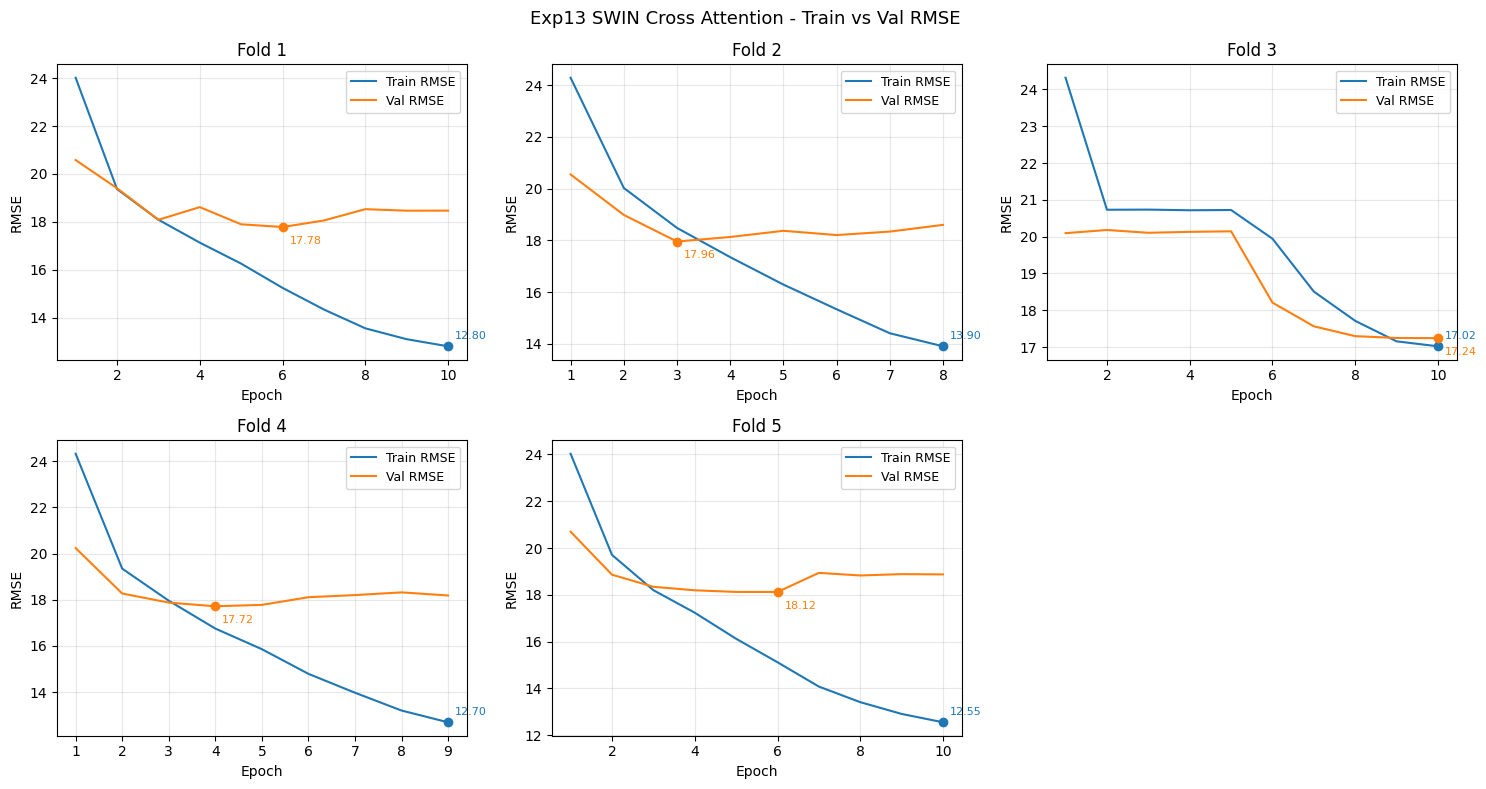

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp13 SWIN Cross Attention")

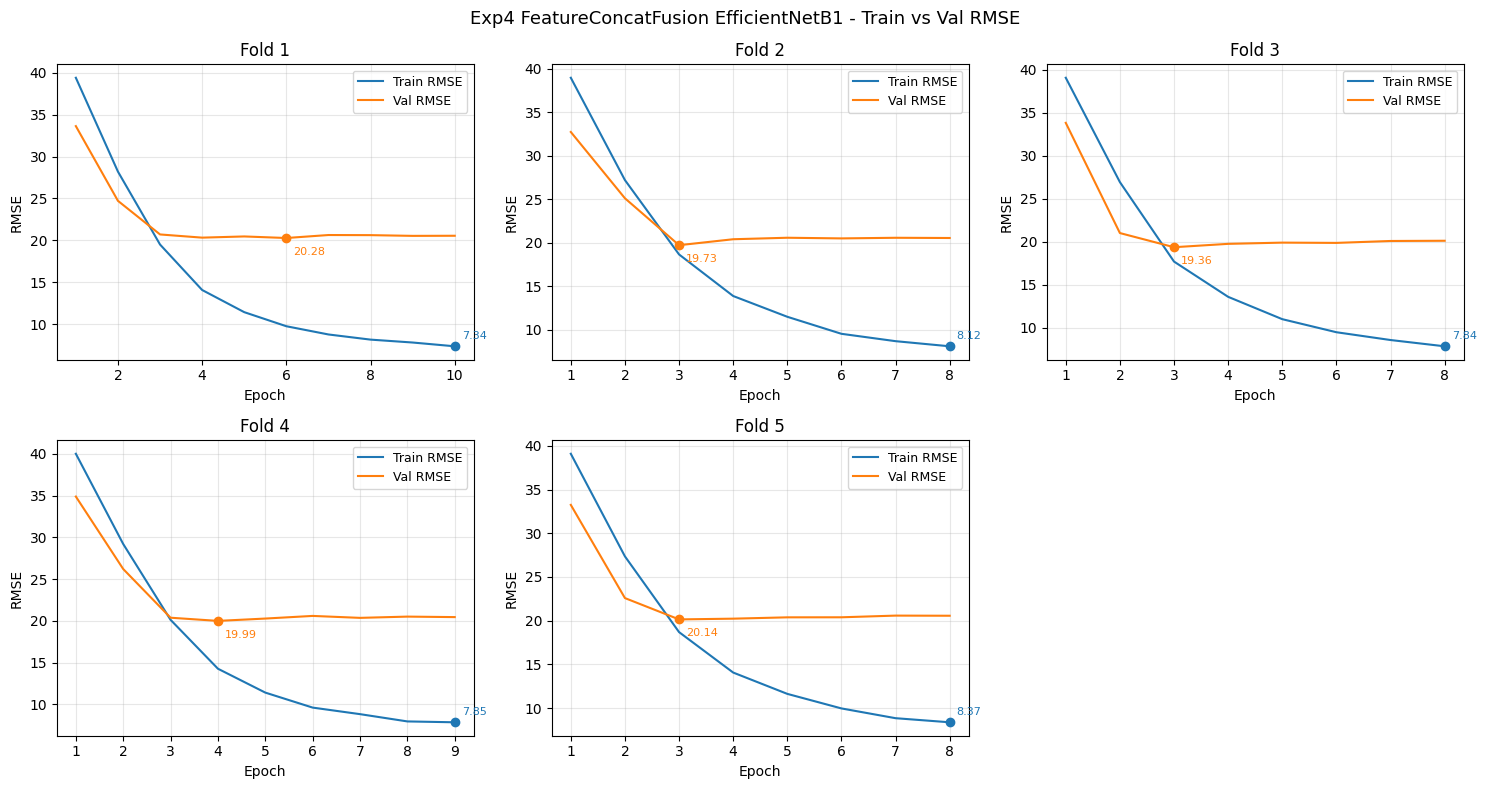

In [7]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

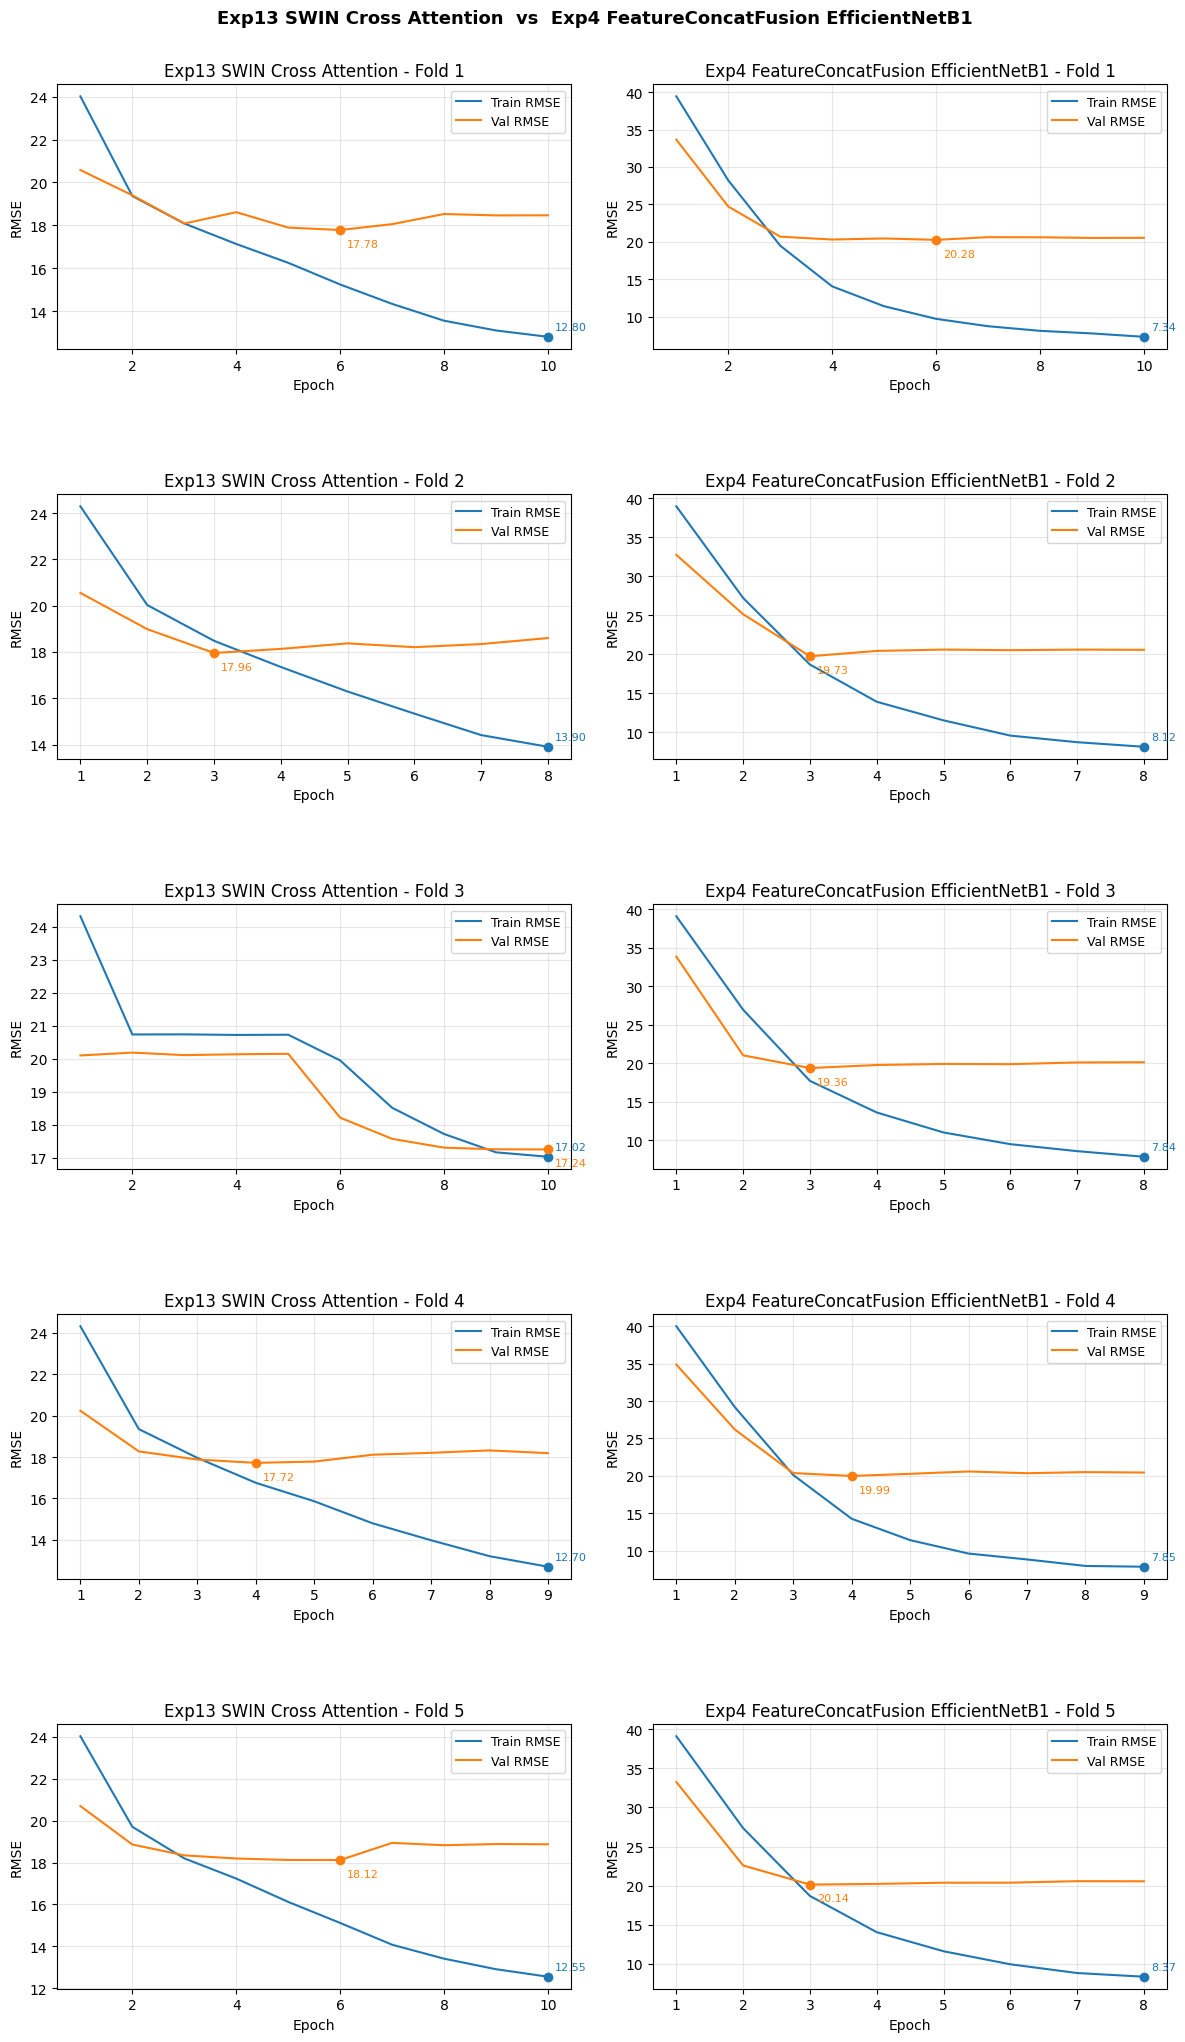

In [8]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp13 SWIN Cross Attention", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

In [9]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4435d6f98ad72782ca0cf61f946b016d,5,100,24.624596,75.375404
1,7550fac99f357d3f540fe15e9ed50e20,5,100,27.100227,72.899773
2,e638853bdec13e6cc76b69f169b34740,4,96,23.827244,72.172756
3,f4dd9ea389798d703ee5ebe2a82c8653,5,2,74.025513,72.025513
4,48a66727373de4e7fa7bb3331cd9acc8,3,96,24.037111,71.962889


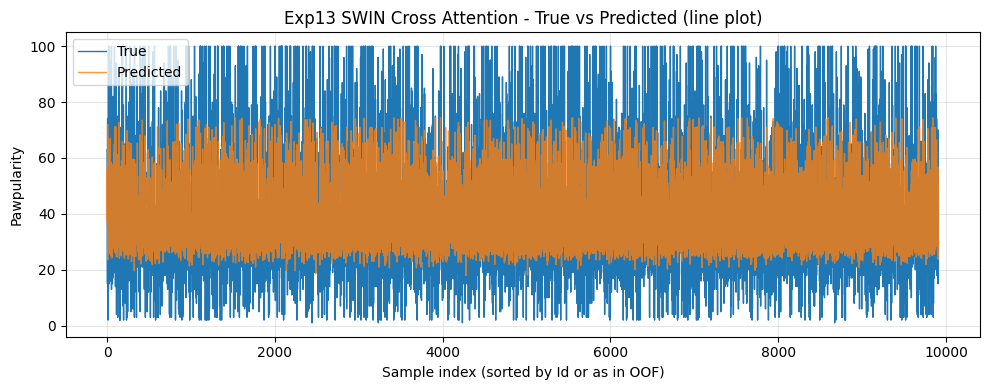

In [10]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp13 SWIN Cross Attention")





Exp13 SWIN Cross Attention OOF RMSE: 17.766517562472632
Exp4_FeatureConcat EffB1 Fusion OOF RMSE: 19.90331621767278
ΔRMSE (Exp4_FeatureConcat EffB1 Fusion - Exp13 SWIN Cross Attention): 2.136798655200149


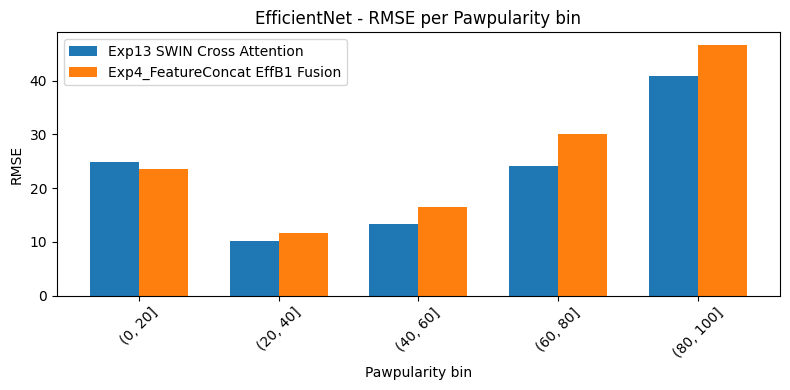

In [11]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp13 SWIN Cross Attention",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

In [12]:
df_bins.head()

,bin,count,Exp13 SWIN Cross Attention_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.811742,23.561754,-1.249988,Exp4_FeatureConcat EffB1 Fusion_better
1,"(20, 40]",5119,10.156065,11.605182,1.449116,Exp13 SWIN Cross Attention_better
2,"(40, 60]",2088,13.316998,16.538259,3.221261,Exp13 SWIN Cross Attention_better
3,"(60, 80]",727,24.103533,30.127592,6.024059,Exp13 SWIN Cross Attention_better
4,"(80, 100]",561,40.840345,46.623998,5.783654,Exp13 SWIN Cross Attention_better


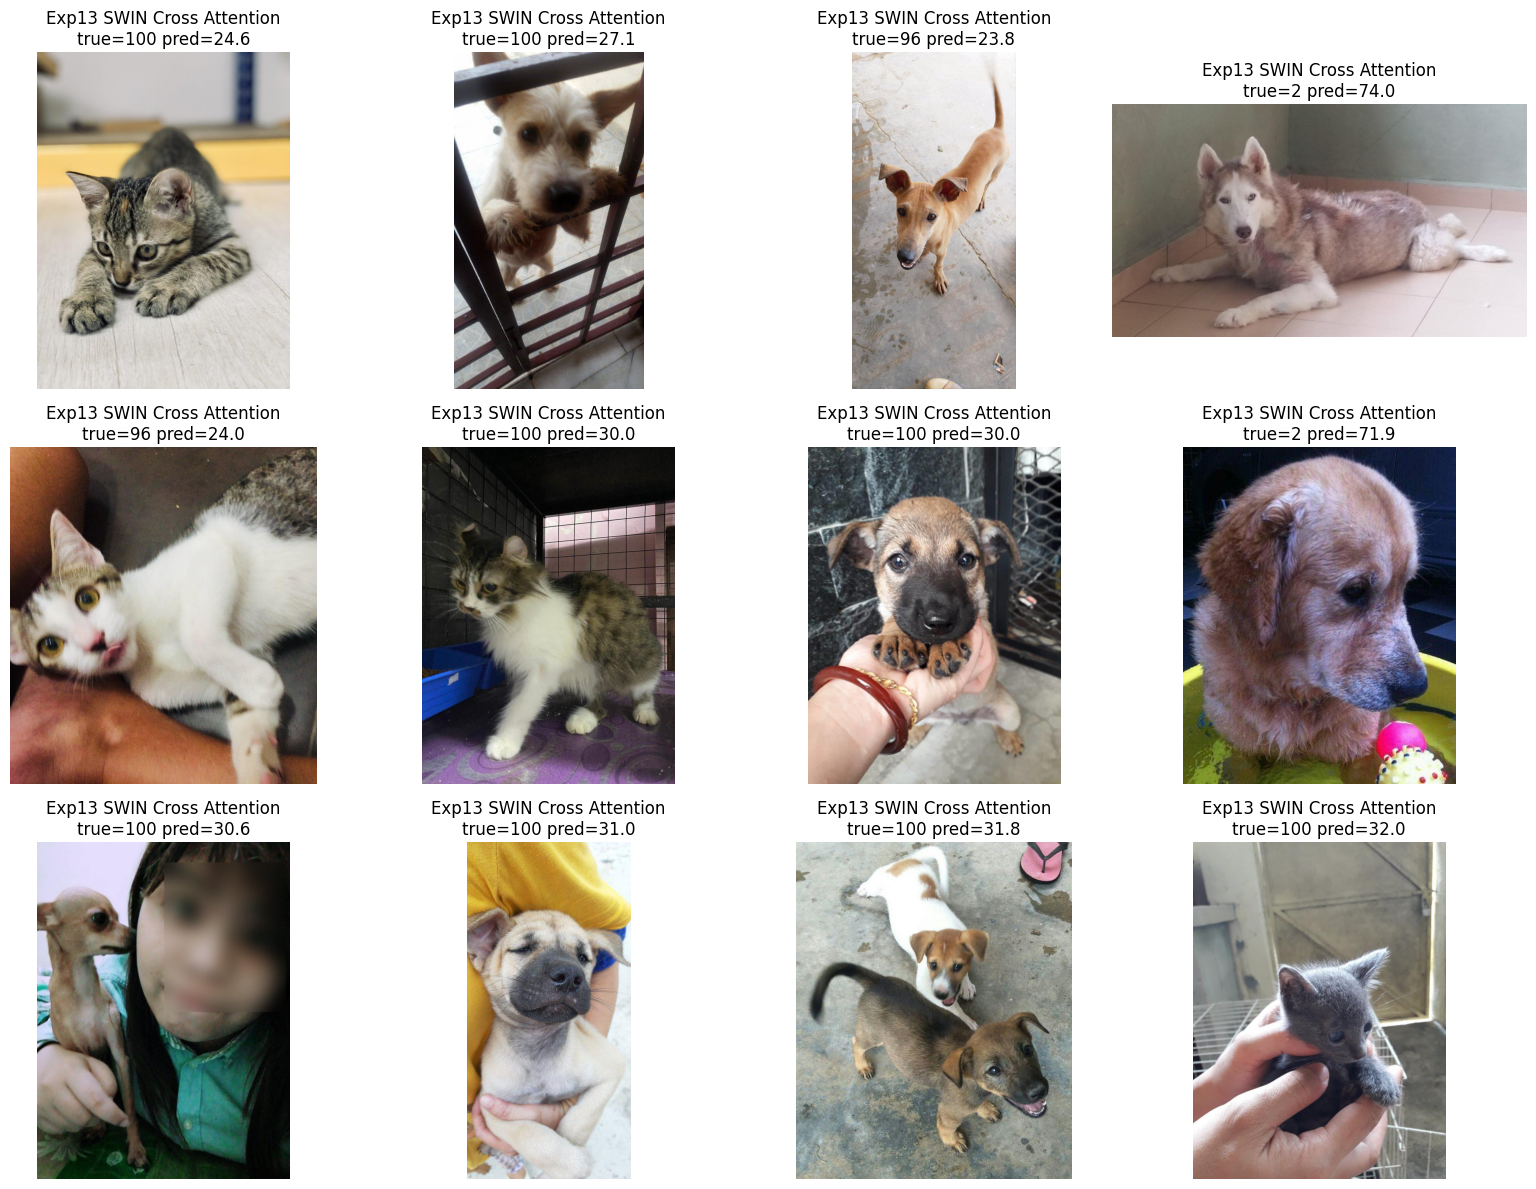

In [13]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp13 SWIN Cross Attention")

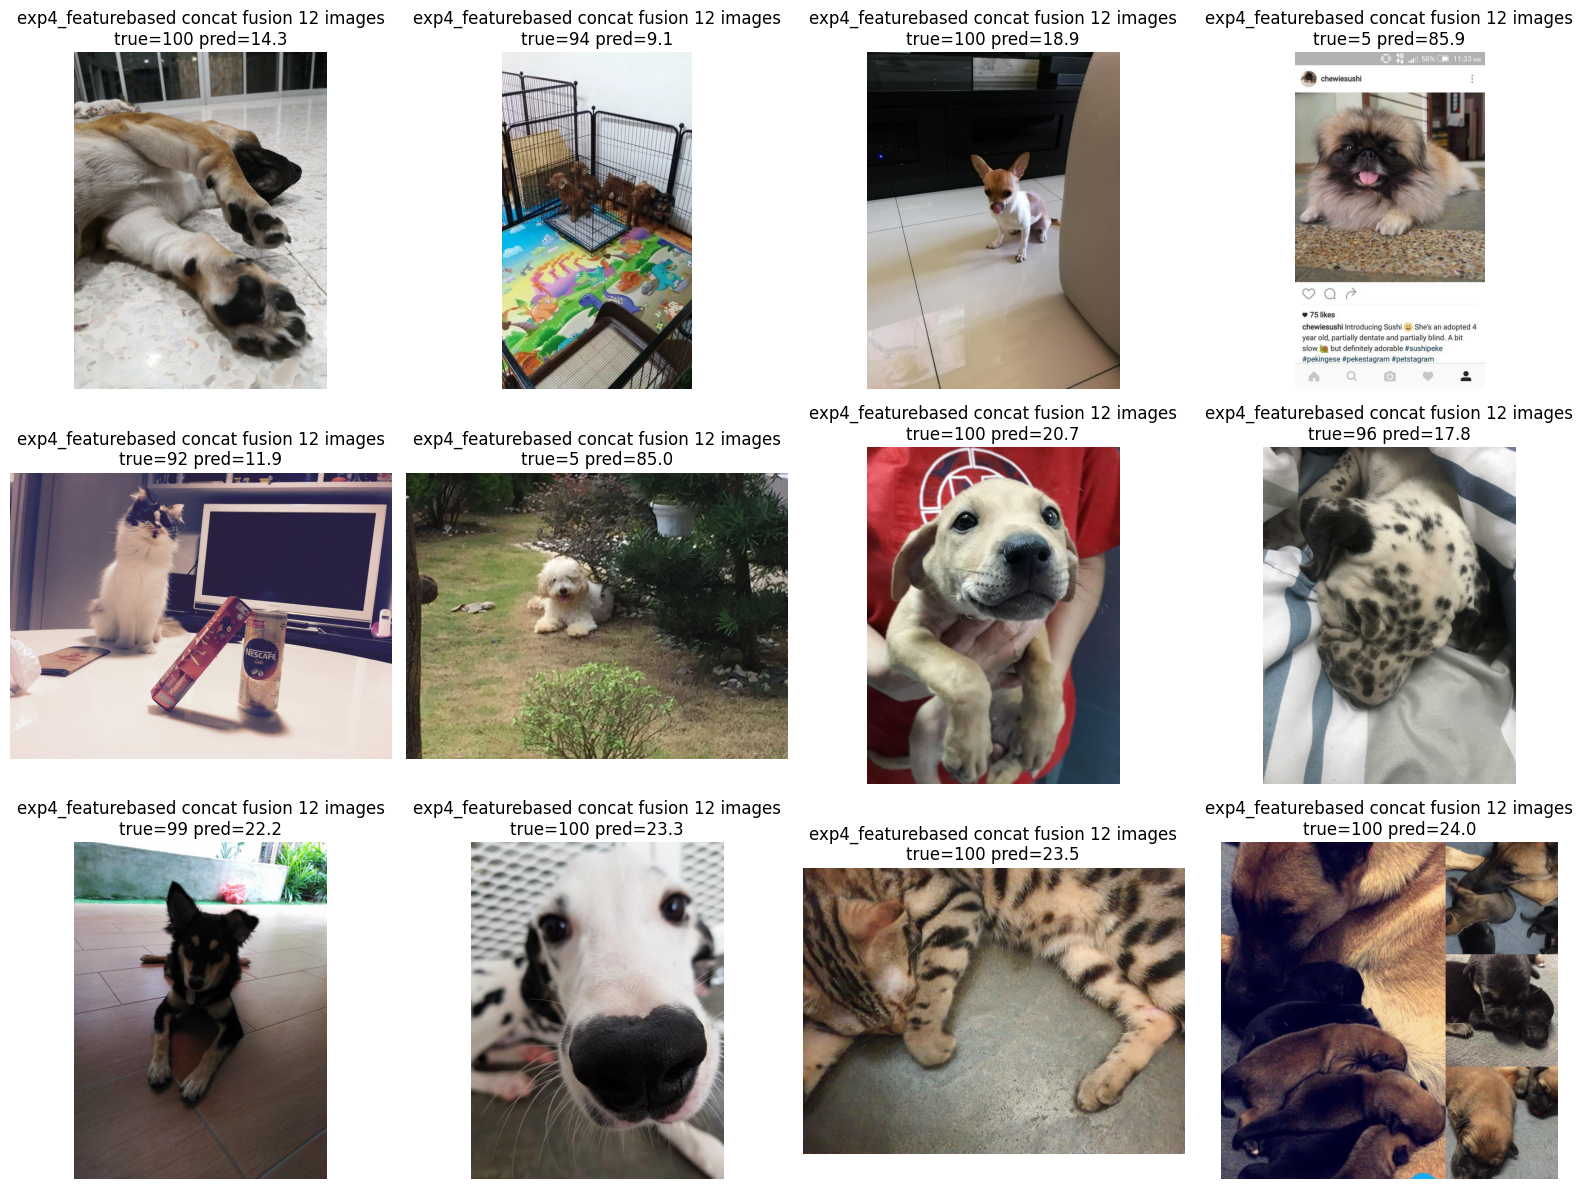

In [14]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")